# micrograd — Building & Training a Neural Net (clean & structured)

*A rewrite of Andrej Karpathy's second-half micrograd notebook, reorganized with clearer explanations and extra examples.*

In **Part 1** we built `Value`: a scalar that remembers how it was computed and can push gradients backward through the chain rule. That's the **autograd engine**.

In this notebook we do the fun part — we build a small **neural network library** *on top of* `Value`, exactly mirroring PyTorch's API (`Neuron`, `Layer`, `MLP`, `.parameters()`), and then we **train** a network with gradient descent.

**The one idea to hold onto:** a neural network is just one big mathematical expression made of the same little `+`, `*`, and activation operations we already implemented. Nothing new happens at the neuron level — it's `Value` objects all the way down. Training is just: build the expression, run `.backward()`, and nudge every parameter a little in the direction that lowers the loss.

---
### Roadmap
1. The `Value` engine (recap, full code)
2. A worked example + a numerical gradient check
3. Visualizing the computation graph
4. A single **Neuron**
5. A **Layer** of neurons
6. An **MLP** (multi-layer perceptron)
7. A tiny dataset + the loss function
8. The training loop (and the famous `zero_grad` bug)
9. Bonus: learning a non-linear decision boundary
10. Exercises


## 0. Setup

In [ ]:
"""Environment setup.

We only rely on the standard library plus NumPy and Matplotlib:
    - math   : math.exp for the tanh / exp activations
    - random : weight initialization and mini-batch sampling
    - numpy  : vectorized data handling for the two-moons demo
    - matplotlib : loss curves and decision-boundary plots

The two seeds below make every run of this notebook fully reproducible:
`random` drives weight init, while `numpy` drives dataset generation and
mini-batch shuffling. Change the seed to explore different random starts.
"""
import math
import random

import numpy as np
import matplotlib.pyplot as plt

random.seed(1337)   # seeds Python's RNG  -> reproducible weights
np.random.seed(1337)  # seeds NumPy's RNG -> reproducible data / batches
%matplotlib inline


## 1. The `Value` engine (recap)

Below is the complete engine from Part 1, gathered in one clean class. Read it as a set of small, independent rules — each operation knows two things:

- **forward:** how to compute its output number from its inputs
- **backward:** its *local derivative* — how a small change in each input changes the output

The magic is that if every tiny operation knows its own local derivative, then `backward()` can chain them together (that's the chain rule) to get the gradient of the *final* output with respect to *every* input, no matter how deep the expression.

A few implementation notes:
- `grad` starts at `0.0` and we **accumulate** into it with `+=`. This matters when a value is used more than once (its gradient contributions must add up — the multivariable chain rule).
- `_backward` is a small closure stored on each output node; it knows how to send gradient to that node's inputs.
- `backward()` first builds a **topological order** of the graph so every node is processed only after everything that depends on it — then walks it in reverse.


In [ ]:
class Value:
    """A single scalar node in a reverse-mode automatic-differentiation graph.

    Every arithmetic operation on ``Value`` objects returns a **new** ``Value``
    that remembers:
      * ``data``   - the forward-pass number it currently holds,
      * ``_prev``  - the input ``Value``s that produced it (its children),
      * ``_op``    - a label for the operation (used only for debugging/viz),
      * ``_backward`` - a closure that knows this op's *local derivative* and
        pushes gradient from this node back onto its inputs.

    Calling :meth:`backward` on the final output performs the full reverse pass:
    it topologically orders the graph and applies each node's ``_backward`` from
    output to inputs, leaving the correct ``grad`` on every node.

    Attributes:
        data (float): The scalar value from the forward pass.
        grad (float): d(final output)/d(this node); accumulated during backward.
    """

    def __init__(self, data, _children=(), _op=''):
        """Create a leaf (or intermediate) node.

        Args:
            data (float): The scalar this node holds.
            _children (tuple[Value, ...]): Inputs that produced this node.
                Empty for user-created leaves (inputs, weights, biases).
            _op (str): Human-readable name of the producing op (for viz/debug).
        """
        self.data = data
        self.grad = 0.0
        # --- internal bookkeeping for building the computation graph ---
        self._backward = lambda: None   # how to route gradient to inputs
        self._prev = set(_children)     # the Values that produced this one
        self._op = _op                  # the op that produced this (for debug/viz)

    # ---- addition -------------------------------------------------
    def __add__(self, other):
        """Element-wise addition: ``out = self + other``.

        Local derivatives are both 1, so each input simply receives a copy of
        the incoming gradient (``out.grad``).
        """
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            # d(out)/d(self) = 1, d(out)/d(other) = 1
            self.grad  += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    # ---- multiplication -------------------------------------------
    def __mul__(self, other):
        """Multiplication: ``out = self * other``.

        By the product rule the local derivative w.r.t. one factor is the *other*
        factor, so each input receives ``(other factor) * out.grad``.
        """
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            # d(out)/d(self) = other, d(out)/d(other) = self
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    # ---- power (by a constant) ------------------------------------
    def __pow__(self, other):
        """Raise to a constant power: ``out = self ** other``.

        Only integer/float exponents are supported (the exponent is a constant,
        not a differentiable ``Value``). Uses the power rule d(x**n)/dx = n*x**(n-1).
        """
        assert isinstance(other, (int, float)), "only int/float powers supported"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            # d(x**n)/dx = n * x**(n-1)
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    # ---- activation functions -------------------------------------
    def relu(self):
        """Rectified linear unit: ``out = max(0, self)``.

        Gradient passes through unchanged where the input was positive and is
        blocked (zero) where it was negative; at exactly 0 the derivative is
        taken as 0 by convention.
        """
        out = Value(0.0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            # gradient passes through only where the input was positive
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        """Hyperbolic tangent activation, squashing inputs into (-1, 1).

        Computed as ``(exp(2x)-1)/(exp(2x)+1)`` with a guard: for |x| > 20 we
        return +/-1 directly so ``math.exp`` cannot overflow. The derivative is
        the well-known ``1 - tanh(x)**2``.
        """
        x = self.data
        # (exp(2x)-1)/(exp(2x)+1); clamp large |x| so exp() can't overflow
        if x > 20:    t = 1.0
        elif x < -20: t = -1.0
        else:
            e = math.exp(2 * x)
            t = (e - 1) / (e + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            # d(tanh)/dx = 1 - tanh(x)**2
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        """Natural exponential: ``out = e**self``.

        Convenient because the derivative of ``e^x`` is ``e^x`` itself, which is
        exactly ``out.data`` and needs no recomputation.
        """
        out = Value(math.exp(self.data), (self,), 'exp')

        def _backward():
            # d(e^x)/dx = e^x  (== out.data)
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    # ---- the backward pass ----------------------------------------
    def backward(self):
        """Run reverse-mode autodiff from this node.

        Steps:
            1. Build a topological ordering so every node appears *after* all of
               its children (the nodes it depends on).
            2. Seed this node's gradient with 1.0 (d(self)/d(self) = 1).
            3. Walk the order in reverse, calling each node's ``_backward`` so
               gradient flows from the output back to every leaf.

        After this returns, ``grad`` on every reachable node holds
        d(self)/d(that node). Note gradients are *accumulated* (``+=``), so reset
        them (see ``Module.zero_grad``) before re-running on the same graph.
        """
        # 1) build a topological ordering of all nodes in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # 2) seed the output gradient with 1.0 (d(self)/d(self) = 1)
        self.grad = 1.0
        # 3) apply each node's local backward rule, from output to inputs
        for node in reversed(topo):
            node._backward()

    # ---- niceties so operators work in any order ------------------
    # These delegate to the core ops above so expressions read naturally,
    # e.g. ``2 * x``, ``x - 1``, ``1 / x`` all work regardless of operand order.
    def __neg__(self):        return self * -1            # -self
    def __radd__(self, other): return self + other        # other + self
    def __sub__(self, other):  return self + (-other)     # self - other
    def __rsub__(self, other): return other + (-self)     # other - self
    def __rmul__(self, other): return self * other        # other * self
    def __truediv__(self, other):  return self * other ** -1   # self / other
    def __rtruediv__(self, other): return other * self ** -1   # other / self

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


## 2. A worked example + a gradient check

Let's run a moderately tangled expression forward, then call `backward()` and read off the gradients of the output `g` with respect to the inputs `a` and `b`.


In [3]:
a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f

print(f"g = {g.data:.4f}")        # the forward pass result
g.backward()
print(f"dg/da = {a.grad:.4f}")    # gradient w.r.t. a
print(f"dg/db = {b.grad:.4f}")    # gradient w.r.t. b

g = 24.7041
dg/da = 138.8338
dg/db = 645.5773


### Are those gradients actually correct?

A gradient is just a slope: *"if I nudge this input by a tiny amount `h`, how much does the output move?"* We can approximate that directly with a **finite difference** and check it against what `backward()` computed. If our analytic engine is right, the two numbers should nearly match.

$$\frac{\partial g}{\partial a} \approx \frac{g(a+h) - g(a-h)}{2h}$$

This *numerical gradient check* is the single best way to catch a bug in a backward rule.


In [ ]:
def compute_g(av, bv):
    """Recompute the scalar ``g`` from raw floats ``av`` and ``bv``.

    Rebuilding the whole expression from plain numbers lets us perturb a single
    input by a tiny ``h`` and measure how ``g`` responds - the basis of the
    finite-difference gradient check below.

    Args:
        av (float): Value to use for ``a``.
        bv (float): Value to use for ``b``.

    Returns:
        float: The forward-pass result ``g.data``.
    """
    a = Value(av); b = Value(bv)
    c = a + b
    d = a * b + b**3
    c = c + (c + 1)
    c = c + (1 + c + (-a))
    d = d + (d * 2 + (b + a).relu())
    d = d + (3 * d + (b - a).relu())
    e = c - d
    f = e**2
    g = f / 2.0
    g = g + 10.0 / f
    return g.data

# central-difference approximation: (g(x+h) - g(x-h)) / 2h
h = 1e-6
num_da = (compute_g(-4.0 + h, 2.0) - compute_g(-4.0 - h, 2.0)) / (2 * h)
num_db = (compute_g(-4.0, 2.0 + h) - compute_g(-4.0, 2.0 - h)) / (2 * h)

print(f"analytic dg/da = {a.grad:.4f}   |   numeric dg/da = {num_da:.4f}")
print(f"analytic dg/db = {b.grad:.4f}   |   numeric dg/db = {num_db:.4f}")


analytic dg/da = 138.8338   |   numeric dg/da = 138.8338
analytic dg/db = 645.5773   |   numeric dg/db = 645.5773


They match — our backward pass is trustworthy. Keep this trick in mind: whenever you add a new operation (say `sin` or `log`), write its `_backward` and immediately gradient-check it.

## 3. Visualizing the computation graph

It helps enormously to *see* the DAG (directed acyclic graph) that `Value` builds. Each operation becomes a node; each node shows its **data** (left) and **grad** (right). The helper below uses `graphviz`.

If `graphviz` isn't installed on your machine, this one cell will just print a note — everything else in the notebook still works.


In [ ]:
def trace(root):
    """Walk the graph backwards from ``root`` and collect its nodes and edges.

    Args:
        root (Value): The output node to trace from.

    Returns:
        tuple[set[Value], set[tuple[Value, Value]]]: All reachable nodes and the
        directed ``(child, parent)`` edges connecting them.
    """
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, rankdir='LR'):
    """Render the computation graph rooted at ``root`` as a Graphviz diagram.

    Each ``Value`` becomes a record node labeled with its ``data`` and ``grad``;
    each operation becomes a small intermediate node feeding its result. This is
    purely a visualization aid and never affects the math.

    Args:
        root (Value): The output node whose graph to draw.
        rankdir (str): Layout direction - ``'LR'`` (left->right) or ``'TB'`` (top->bottom).

    Returns:
        graphviz.Digraph | None: The diagram, or ``None`` if ``graphviz`` isn't
        installed (a hint is printed instead so the rest of the notebook runs).
    """
    try:
        from graphviz import Digraph
    except ImportError:
        print("graphviz not installed - run: pip install graphviz  (and the system 'graphviz' package)")
        return None
    dot = Digraph(format='svg', graph_attr={'rankdir': rankdir})
    nodes, edges = trace(root)
    for n in nodes:
        # a rectangular record node showing the value and its gradient
        dot.node(name=str(id(n)),
                 label=f"{{ data {n.data:.4f} | grad {n.grad:.4f} }}",
                 shape='record')
        if n._op:
            # add an op node (e.g. '+', '*') and connect it into the value node
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    for n1, n2 in edges:
        # connect each child value to the op node that consumed it
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot


A small example: a single 2-input neuron, `tanh(w1*x1 + w2*x2 + b)`. Notice how the numbers on the right (the grads) only appear after we call `.backward()`.

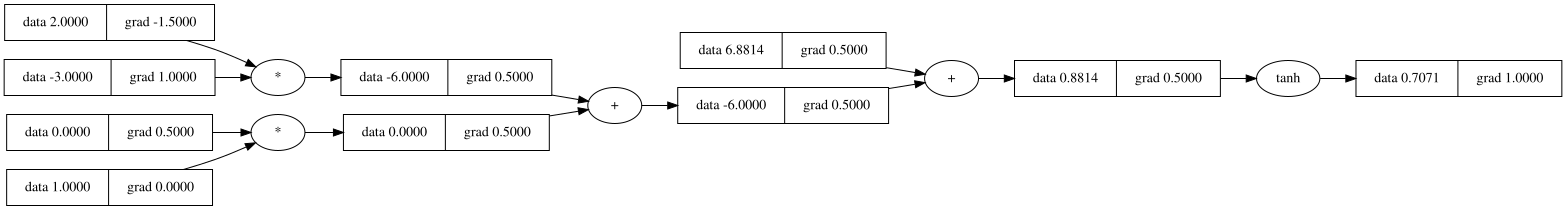

In [6]:
# inputs
x1 = Value(2.0); x2 = Value(0.0)
# weights & bias
w1 = Value(-3.0); w2 = Value(1.0)
b  = Value(6.8813735870195432)
# forward
n = x1*w1 + x2*w2 + b
o = n.tanh()
o.backward()

draw_dot(o)

## 4. A single Neuron

A neuron does two things:

1. a **weighted sum** of its inputs plus a bias:  $\;z = \sum_i w_i x_i + b$
2. a **non-linearity** (activation), here `tanh`:  $\;\text{out} = \tanh(z)$

The weights `w` and bias `b` are the **parameters** — the numbers we'll adjust during training. Everything is a `Value`, so gradients flow through a neuron automatically.

We give every module a `parameters()` method (just like PyTorch's `nn.Module`) so the optimizer can find every knob to turn. `zero_grad()` resets all gradients to zero — you'll see why that's essential in Section 8.


In [ ]:
class Module:
    """Base class for all network components (mirrors PyTorch's ``nn.Module``).

    Provides two shared conveniences:
      * :meth:`parameters` - the list of trainable ``Value``s (overridden below),
      * :meth:`zero_grad`  - reset every parameter's gradient to 0 before a
        backward pass (critical because our engine *accumulates* gradients).
    """
    def zero_grad(self):
        """Reset ``.grad`` to 0 on every parameter owned by this module."""
        for p in self.parameters():
            p.grad = 0.0
    def parameters(self):
        """Return this module's trainable parameters (none by default)."""
        return []

class Neuron(Module):
    """A single neuron: an optional non-linearity applied to ``w . x + b``.

    Args:
        nin (int): Number of inputs (and hence weights).
        nonlin (bool): If ``True`` apply a ``tanh`` activation; if ``False`` the
            neuron is linear (typical for an output neuron).
    """
    def __init__(self, nin, nonlin=True):
        # one weight per input, initialized randomly in [-1, 1]; bias starts at 0
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)
        self.nonlin = nonlin   # apply tanh? (output neuron often linear)

    def __call__(self, x):
        """Forward pass: compute ``tanh(w . x + b)`` (or the raw sum if linear).

        Args:
            x (list[Value | float]): Input vector of length ``nin``.

        Returns:
            Value: The neuron's scalar activation.
        """
        # w . x + b  (the bias seeds sum() so the dot product folds into it)
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh() if self.nonlin else act

    def parameters(self):
        """Return the weights followed by the bias."""
        return self.w + [self.b]

    def __repr__(self):
        kind = 'TanH' if self.nonlin else 'Linear'
        return f"{kind}Neuron({len(self.w)})"


In [8]:
# Example: a neuron that takes 2 inputs
n = Neuron(2)
x = [Value(1.0), Value(-2.0)]
out = n(x)
print("neuron:", n)
print("output:", out)
print("number of parameters:", len(n.parameters()), "->", n.parameters())

neuron: TanHNeuron(2)
output: Value(data=0.10208654808418723, grad=0.0)
number of parameters: 3 -> [Value(data=0.23550571390294128, grad=0.0), Value(data=0.06653114721000164, grad=0.0), Value(data=0.0, grad=0.0)]


## 5. A Layer of neurons

A **layer** is simply a list of independent neurons that all read the same inputs and each produce one output. A layer with `nout` neurons turns an input vector into an output vector of length `nout`.

(If a layer has exactly one neuron we return a bare `Value` instead of a length-1 list, purely for convenience.)


In [ ]:
class Layer(Module):
    """A fully-connected layer: ``nout`` independent neurons sharing the inputs.

    Maps an input vector of length ``nin`` to an output vector of length ``nout``.

    Args:
        nin (int): Number of inputs each neuron receives.
        nout (int): Number of neurons (and outputs) in the layer.
        **kwargs: Forwarded to each ``Neuron`` (e.g. ``nonlin=False``).
    """
    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        """Run every neuron on ``x``.

        Returns:
            Value | list[Value]: A single ``Value`` when the layer has one
            neuron (for convenience), otherwise a list of outputs.
        """
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        """Flatten and return the parameters of every neuron in the layer."""
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"


In [10]:
# Example: a layer mapping 2 inputs -> 3 outputs
layer = Layer(2, 3)
x = [Value(1.0), Value(-2.0)]
outs = layer(x)
print("layer:", layer)
print("outputs:", outs)
print("total parameters:", len(layer.parameters()), "  (3 neurons x (2 weights + 1 bias))")

layer: Layer of [TanHNeuron(2), TanHNeuron(2), TanHNeuron(2)]
outputs: [Value(data=-0.5451488812956724, grad=0.0), Value(data=-0.9615541208360555, grad=0.0), Value(data=-0.8833998578839038, grad=0.0)]
total parameters: 9   (3 neurons x (2 weights + 1 bias))


## 6. The MLP (multi-layer perceptron)

An **MLP** stacks layers so the outputs of one become the inputs of the next. We describe its shape with `MLP(nin, [h1, h2, ..., nout])`.

One nice touch: we make the **last** layer *linear* (no `tanh`), because for regression/margin-style outputs we don't want to squash the final score into `[-1, 1]`.


In [ ]:
class MLP(Module):
    """A multi-layer perceptron: a stack of :class:`Layer`s fed head-to-tail.

    The final layer is made **linear** (``nonlin=False``) so the network can emit
    unbounded scores for regression / max-margin objectives instead of being
    squashed into ``(-1, 1)`` by a ``tanh``.

    Args:
        nin (int): Size of the input vector.
        nouts (list[int]): Output size of each layer, e.g. ``[4, 4, 1]`` builds
            two hidden layers of 4 and a single-unit output layer.
    """
    def __init__(self, nin, nouts):
        sizes = [nin] + nouts
        self.layers = [
            Layer(sizes[i], sizes[i + 1], nonlin=(i != len(nouts) - 1))
            for i in range(len(nouts))
        ]

    def __call__(self, x):
        """Forward the input through each layer in sequence."""
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        """Flatten and return every parameter across all layers."""
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(l) for l in self.layers)}]"


In [12]:
# A 3-input network with two hidden layers of 4, and a single output
model = MLP(3, [4, 4, 1])
x = [2.0, 3.0, -1.0]
print(model)
print("prediction:", model(x))
print("number of parameters:", len(model.parameters()))

MLP of [Layer of [TanHNeuron(3), TanHNeuron(3), TanHNeuron(3), TanHNeuron(3)], Layer of [TanHNeuron(4), TanHNeuron(4), TanHNeuron(4), TanHNeuron(4)], Layer of [LinearNeuron(4)]]
prediction: Value(data=-0.4135029187145921, grad=0.0)
number of parameters: 41


We can visualize the whole thing. This graph is already fairly large — remember, micrograd chops every neuron into individual `+` and `*` nodes, which is why it's so slow but so transparent.

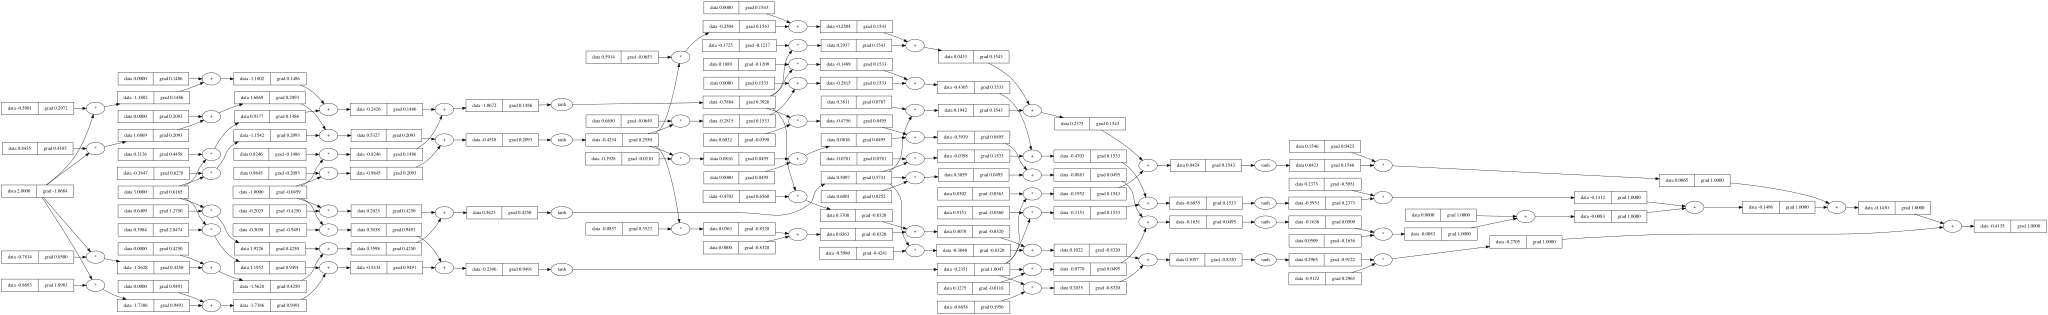

In [13]:
y = model([Value(2.0), Value(3.0), Value(-1.0)])
y.backward()
draw_dot(y)

## 7. A tiny dataset + the loss

Let's give the network something to learn. Four input examples, each with a desired output (`+1` or `-1`) — a toy binary classification problem.


In [14]:
xs = [
    [2.0,  3.0, -1.0],
    [3.0, -1.0,  0.5],
    [0.5,  1.0,  1.0],
    [1.0,  1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]   # desired targets

# a fresh model
model = MLP(3, [4, 4, 1])

# current predictions (untrained -> basically random)
ypred = [model(x) for x in xs]
for target, pred in zip(ys, ypred):
    print(f"target={target:+.1f}   pred={pred.data:+.4f}")

target=+1.0   pred=+0.1677
target=-1.0   pred=+0.6090
target=-1.0   pred=+0.2263
target=+1.0   pred=+0.1250


### The loss

The **loss** is a single number that measures how wrong the network currently is. We use **mean squared error**: square each mistake (so sign doesn't matter and big misses hurt more), then add them up.

$$\text{loss} = \sum_i (\text{pred}_i - \text{target}_i)^2$$

Because `xs`, the model, and the arithmetic are all `Value` objects, the loss is the single root of one giant computation graph. Calling `loss.backward()` fills in `.grad` for **every parameter** at once — telling us, for each weight, whether nudging it up or down would reduce the loss.


In [ ]:
def compute_loss(model, xs, ys):
    """Mean-squared-error loss over the whole toy dataset.

    Args:
        model (MLP): The network to evaluate.
        xs (list[list[float]]): Input examples.
        ys (list[float]): Desired target for each example.

    Returns:
        Value: The summed squared error as a single graph root, so calling
        ``.backward()`` on it populates ``.grad`` for every parameter at once.
    """
    ypred = [model(x) for x in xs]
    return sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

loss = compute_loss(model, xs, ys)
print("initial loss:", loss.data)


initial loss: 5.550982737276053


## 8. The training loop

Training is a loop of four steps repeated many times:

1. **Forward** — compute predictions and the loss.
2. **Zero the gradients** — reset every `p.grad` to `0`.
3. **Backward** — `loss.backward()` fills in every `p.grad`.
4. **Update** — nudge each parameter *against* its gradient: `p.data -= lr * p.grad`.

Step 4 is **gradient descent**: the gradient points in the direction that *increases* the loss, so we step the opposite way. `lr` (the *learning rate*) controls step size.

### ⚠️ The most famous micrograd bug: forgetting to zero the gradients

Remember our engine *accumulates* gradients with `+=`. If you don't reset them before each `backward()`, gradients from previous iterations pile up, your steps get wildly too large, and training becomes unstable. **Always `zero_grad()` before `backward()`.** This is such a common mistake that PyTorch users hit it constantly too.


In [16]:
model = MLP(3, [4, 4, 1])   # start fresh
learning_rate = 0.05

for step in range(100):
    # 1. forward
    loss = compute_loss(model, xs, ys)

    # 2. zero gradients  (do NOT skip this!)
    model.zero_grad()

    # 3. backward
    loss.backward()

    # 4. update
    for p in model.parameters():
        p.data += -learning_rate * p.grad

    if step % 10 == 0 or step == 99:
        print(f"step {step:3d}   loss {loss.data:.6f}")

step   0   loss 3.663234
step  10   loss 0.007808
step  20   loss 0.001843


step  30   loss 0.000494
step  40   loss 0.000140
step  50   loss 0.000041
step  60   loss 0.000012


step  70   loss 0.000004
step  80   loss 0.000001
step  90   loss 0.000000
step  99   loss 0.000000


In [17]:
# Final predictions - should be close to the targets [+1, -1, -1, +1]
print("target   prediction")
for target, x in zip(ys, xs):
    print(f"{target:+.1f}      {model(x).data:+.4f}")

target   prediction
+1.0      +0.9998
-1.0      -1.0000
-1.0      -1.0000
+1.0      +1.0002


The loss dropped to near zero and the predictions match the targets. **You just trained a neural network from scratch** — no PyTorch, no autograd library, just the `Value` object we built by hand.

### Experiment: the learning rate matters

Try re-running the loop with different learning rates and watch the loss curve. Too small → painfully slow. Too big → it overshoots and the loss bounces around or explodes.


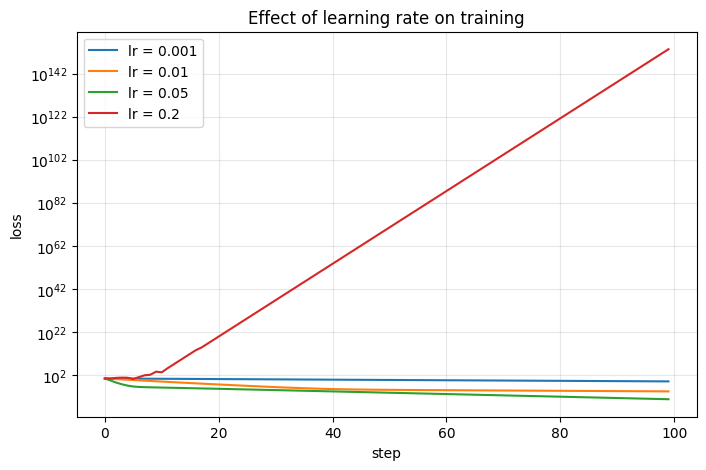

In [ ]:
def train(lr, steps=100, seed=1337):
    """Train a fresh MLP on the toy dataset and record the loss each step.

    Args:
        lr (float): Learning rate (gradient-descent step size).
        steps (int): Number of full-batch update steps.
        seed (int): RNG seed so every learning-rate curve starts from the same
            random weights, making the comparison fair.

    Returns:
        list[float]: The loss value after each step (its training curve).
    """
    random.seed(seed)
    m = MLP(3, [4, 4, 1])
    history = []
    for _ in range(steps):
        loss = compute_loss(m, xs, ys)   # 1. forward
        m.zero_grad()                    # 2. clear old gradients
        loss.backward()                  # 3. backward
        for p in m.parameters():         # 4. gradient-descent update
            p.data += -lr * p.grad
        history.append(loss.data)
    return history

plt.figure(figsize=(8, 5))
for lr in [0.001, 0.01, 0.05, 0.2]:
    plt.plot(train(lr), label=f"lr = {lr}")
plt.xlabel("step"); plt.ylabel("loss"); plt.yscale("log")
plt.title("Effect of learning rate on training")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


## 9. Bonus: learning a curved decision boundary

Four points is cute, but let's give micrograd a real (if small) challenge: the classic **two moons** dataset — two interleaving crescents that *cannot* be separated by a straight line. A network with hidden layers can bend its decision boundary to fit them.

This mirrors the demo in Karpathy's `demo.ipynb`, using a max-margin (SVM-style) loss with a little L2 regularization.


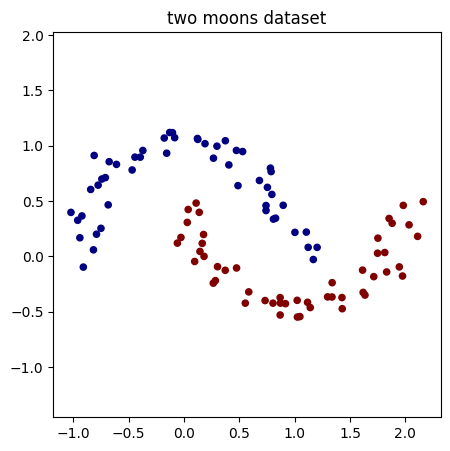

In [19]:
from sklearn.datasets import make_moons

X, yb = make_moons(n_samples=100, noise=0.1, random_state=1337)
yb = yb * 2 - 1  # make labels -1 / +1

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=yb, s=20, cmap='jet')
plt.title("two moons dataset"); plt.axis('equal')
plt.show()

In [ ]:
model = MLP(2, [16, 16, 1])   # 2 inputs -> two hidden layers of 16 -> 1 output
print(model)
print("number of parameters:", len(model.parameters()))

def loss_fn(batch_size=None):
    """Compute the SVM max-margin loss (with L2 regularization) and accuracy.

    Args:
        batch_size (int | None): If given, evaluate on a random mini-batch of
            that many points; otherwise use the full dataset.

    Returns:
        tuple[Value, float]: The total loss (a differentiable graph root) and the
        classification accuracy in ``[0, 1]`` for reporting.
    """
    # optionally use a mini-batch
    if batch_size is None:
        Xb, yrow = X, yb
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yrow = X[ri], yb[ri]
    # wrap raw coordinates as Value objects so gradients can flow
    inputs = [[Value(x[0]), Value(x[1])] for x in Xb]

    scores = [model(x) for x in inputs]

    # SVM "max-margin" loss: penalize points inside the +/-1 margin
    losses = [(1 + -yi * scorei).relu() for yi, scorei in zip(yrow, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))   # average over the batch
    # L2 regularization: gently shrink weights to curb overfitting
    alpha = 1e-4
    reg_loss = alpha * sum((p * p for p in model.parameters()))
    total = data_loss + reg_loss

    # accuracy = fraction whose predicted sign matches the label sign
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yrow, scores)]
    return total, sum(accuracy) / len(accuracy)


MLP of [Layer of [TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2), TanHNeuron(2)], Layer of [TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16), TanHNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters: 337


In [21]:
for k in range(100):
    total_loss, acc = loss_fn()
    model.zero_grad()
    total_loss.backward()

    # simple learning-rate decay
    lr = 1.0 - 0.9 * k / 100
    for p in model.parameters():
        p.data += -lr * p.grad

    if k % 10 == 0 or k == 99:
        print(f"step {k:3d}   loss {total_loss.data:.4f}   accuracy {acc*100:.1f}%")

step   0   loss 3.0547   accuracy 21.0%


step  10   loss 0.2731   accuracy 87.0%


step  20   loss 0.2852   accuracy 90.0%


step  30   loss 0.0745   accuracy 97.0%


step  40   loss 0.1514   accuracy 95.0%


...

step  60   loss 0.0202   accuracy 100.0%


step  70   loss 0.0239   accuracy 100.0%


step  80   loss 0.0154   accuracy 100.0%


step  90   loss 0.0143   accuracy 100.0%


step  99   loss 0.0140   accuracy 100.0%


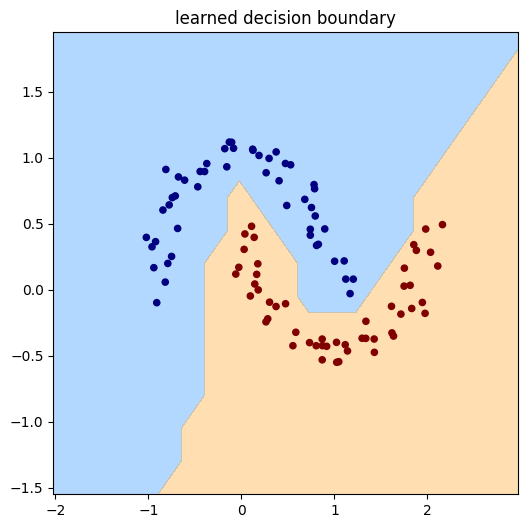

In [22]:
# Visualize the learned decision boundary
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
scores = [model([Value(px[0]), Value(px[1])]) for px in grid]
Z = np.array([s.data > 0 for s in scores]).reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, Z, cmap='jet', alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=yb, s=20, cmap='jet')
plt.xlim(xx.min(), xx.max()); plt.ylim(yy.min(), yy.max())
plt.title("learned decision boundary")
plt.show()

The network carved out a curved boundary that follows the two crescents — something no single straight line could do. That curvature is exactly what the hidden layers + non-linearities buy you.

## 10. Exercises

Try these to cement the ideas (all doable with the code above):

1. **Add a new operation.** Implement `Value.log()` and `Value.sin()` with correct `_backward` rules, then gradient-check them with the finite-difference trick from Section 2.
2. **Break the model on purpose.** Delete the `model.zero_grad()` line in the training loop and watch what happens to the loss. Explain *why* in one sentence.
3. **Swap the activation.** Change `Neuron` to use `relu()` instead of `tanh()`. Does the two-moons model still learn? Does it need a different learning rate?
4. **Depth vs width.** On the two-moons task, compare `MLP(2, [16, 16, 1])`, `MLP(2, [4, 4, 1])`, and `MLP(2, [64, 1])`. Which trains fastest? Which generalizes best?
5. **Mini-batches.** Call `loss_fn(batch_size=16)` inside the loop instead of the full batch. How does the loss curve change (hint: it gets noisier but each step is cheaper)?
6. **Cross-entropy.** Replace the max-margin loss with a softmax + cross-entropy loss and confirm it still separates the moons.

---
*Built on Andrej Karpathy's micrograd. The engine and NN API here match his originals; the structure, commentary, gradient-check, learning-rate study, and exercises are expanded for self-study.*
